# Machine Learning (ML) RQE for automatic detection of the anaerobic threshold (AnT) from heart rate time series data.

Aim: Build a candidate classifier model to improve pipeline's ability to deal with systematic outliers eg. early AnTs. 

Methodology: 
1. Build code to extract minima and their features
2. Build a pd.DataFrame called minima (which will be used as X) - each row is a candidate minimum and its features; other than subject column and index column, each column is a feature: 1. convexity (determinism second derivative), 2. % determinism, 3. time, 4. time fraction, 5. distance from primary window, 6. HR, 7. HR delta, 8. HR fraction.
3. Create labels for true technician labelled AnTs (will be used as y)
4. Compare logistic regression, gradient boosting and random forest models using subject-wise split CV using KGroupFold
5. Test best performing model on holdout subjects and compute MAE and correlations 

## Data Ingestion & Preprocessing

In [1]:
#create new df reading csv file from exported excel file
import pandas as pd
import numpy as np

file = '/Users/adamhu/documents/python/bhri research/aggregated_hr_data.csv'

df = pd.read_csv(file)
df.columns
print(df.head())

   t_001_2024  rq_001_2024  hr_001_2024  t_001_2025  rq_001_2025  hr_001_2025  \
0         3.0         0.81         86.0         7.0         0.81        102.0   
1         6.0         0.78         89.0        11.0         0.76        106.0   
2        11.0         0.79         99.0        13.0         0.74        106.0   
3        17.0         0.83        106.0        16.0         0.77        108.0   
4        22.0         0.85        110.0        20.0         0.83        111.0   

   t_002_2024  rq_002_2024  hr_002_2024  t_002_2025  ...  hr_024_2025  \
0         2.0         0.91        108.0         2.0  ...        122.0   
1         5.0         0.93        109.0         3.0  ...        122.0   
2         8.0         0.98        114.0         6.0  ...        124.0   
3        11.0         0.97        124.0         8.0  ...        127.0   
4        14.0         0.95        128.0        10.0  ...        127.0   

   t_025_2024  rq_025_2024  hr_025_2024  t_025_2025  rq_025_2025  hr_025_2

### Linear Interpolation

In [47]:
import pandas as pd
import numpy as np

# Step 1: Initialize the new DataFrame with 't' from 1 to 850
new_df = pd.DataFrame({'t': range(1, 850)})

# Step 2: Loop through each subject to interpolate and add their 'rq' and 'hr' columns
for i in range(0, int(len(df.columns) / 3)):

    temp_identifier = df.columns[i * 3]
    identifier = temp_identifier[2:]
    
    # Define the column names for each subject in the original DataFrame
    rq_column = f'rq_{identifier}'
    hr_column = f'hr_{identifier}'

    # Extract the original 'rq' and 'hr' series for the current subject
    rq_series = df[rq_column]
    hr_series = df[hr_column]

    # Create a temporary DataFrame for reindexing and interpolation
    temp_df = pd.DataFrame({
        't': df[f't_{identifier}'],
        rq_column: rq_series,
        hr_column: hr_series
    })
    
    # Remove any duplicate time entries in 't'
    temp_df = temp_df.drop_duplicates(subset='t').set_index('t')

    # Reindex to create the full range from 1 to 800 with a 1-second interval
    temp_df = temp_df.reindex(new_df['t'], method=None)

    # Interpolate missing values in 'rq' and 'hr' columns
    temp_df = temp_df.interpolate(method='linear')

    # Add interpolated columns to new_df in the required order
    new_df[f'rq_{identifier}'] = temp_df[rq_column].values
    new_df[f'hr_{identifier}'] = temp_df[hr_column].values

# Use backfill to fill in only the early NaNs for each column
new_df = new_df.bfill()

# Convert all 'hr' columns to integers
hr_columns = [col for col in new_df.columns if col.startswith('hr_')]
new_df[hr_columns] = new_df[hr_columns].astype(int)

# Round all 'rq' columns to two decimal places
rq_columns = [col for col in new_df.columns if col.startswith('rq_')]
new_df[rq_columns] = new_df[rq_columns].round(2)

# Display the head of the new DataFrame to verify
print(new_df.head())

   t  rq_001_2024  hr_001_2024  rq_001_2025  hr_001_2025  rq_002_2024  \
0  1         0.81           86         0.81          102         0.91   
1  2         0.81           86         0.81          102         0.91   
2  3         0.81           86         0.81          102         0.92   
3  4         0.80           87         0.81          102         0.92   
4  5         0.79           88         0.81          102         0.93   

   hr_002_2024  rq_002_2025  hr_002_2025  rq_003_2024  ...  rq_024_2024  \
0          108         0.76           60          0.8  ...         0.81   
1          108         0.76           60          0.8  ...         0.81   
2          108         0.79           60          0.8  ...         0.81   
3          108         0.79           61          0.8  ...         0.76   
4          109         0.80           63          0.8  ...         0.77   

   hr_024_2024  rq_024_2025  hr_024_2025  rq_025_2024  hr_025_2024  \
0          101         0.82          122

### Ground truth AnT Definition

In [48]:
# Anaerobic threshold times in seconds for each subject in order 
AT_secs = [

    195, 105, 283, 82, 320, 335, 391, 422, 473, 358, 521, 379, 
    303, 331, 202, 413, 341, 498, 386, 364, 288, 355, 0, 467, 355, 
    442, 455, 296, 225, 420, 286, 336, 298, 349, 315, 471, 301, 358, 
    494, 107, 425, 411, 302, 302, 385, 284, 270, 532, 375
    
]


print(AT_secs)

[195, 105, 283, 82, 320, 335, 391, 422, 473, 358, 521, 379, 303, 331, 202, 413, 341, 498, 386, 364, 288, 355, 0, 467, 355, 442, 455, 296, 225, 420, 286, 336, 298, 349, 315, 471, 301, 358, 494, 107, 425, 411, 302, 302, 385, 284, 270, 532, 375]


In [49]:
subjects = []

for i in range(0, 49):

    index = 1 + (i * 2)
    temp_identifier = new_df.columns[index]
    identifier = temp_identifier[3:]
    subjects.append(identifier)

AT_dict = {}

for i in range(0, len(subjects)):

    subject = subjects[i]
    dict_temp = {f'{subject}': AT_secs[i]}
    AT_dict.update(dict_temp)
    
print(AT_dict)

{'001_2024': 195, '001_2025': 105, '002_2024': 283, '002_2025': 82, '003_2024': 320, '003_2025': 335, '004_2024': 391, '004_2025': 422, '005_2024': 473, '005_2025': 358, '006_2024': 521, '006_2025': 379, '007_2024': 303, '007_2025': 331, '008_2024': 202, '008_2025': 413, '009_2025': 341, '010_2024': 498, '010_2025': 386, '011_2025': 364, '012_2024': 288, '012_2025': 355, '013_2024': 0, '013_2025': 467, '014_2024': 355, '014_2025': 442, '015_2024': 455, '015_2025': 296, '016_2024': 225, '016_2025': 420, '017_2024': 286, '017_2025': 336, '018_2024': 298, '018_2025': 349, '019_2024': 315, '019_2025': 471, '020_2024': 301, '020_2025': 358, '021_2024': 494, '021_2025': 107, '022_2024': 425, '022_2025': 411, '023_2024': 302, '023_2025': 302, '024_2024': 385, '024_2025': 284, '025_2024': 270, '025_2025': 532, '026_2025': 375}


In [50]:
print(new_df)

       t  rq_001_2024  hr_001_2024  rq_001_2025  hr_001_2025  rq_002_2024  \
0      1         0.81           86         0.81          102         0.91   
1      2         0.81           86         0.81          102         0.91   
2      3         0.81           86         0.81          102         0.92   
3      4         0.80           87         0.81          102         0.92   
4      5         0.79           88         0.81          102         0.93   
..   ...          ...          ...          ...          ...          ...   
844  845         1.16          170         1.32          116         1.36   
845  846         1.16          170         1.32          116         1.38   
846  847         1.16          170         1.32          116         1.39   
847  848         1.16          170         1.32          116         1.40   
848  849         1.16          170         1.32          116         1.42   

     hr_002_2024  rq_002_2025  hr_002_2025  rq_003_2024  ...  rq_024_2024  

### Prototyping minima & feature extraction using first subject 001_2024

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.computation import RQAComputation
from pyrqa.neighbourhood import FixedRadius

# Define parameters
time_interval = 1
epoch_length = 125
step_size = 1
embedding_dim = 7
time_delay = 1
radius = 5
min_diag_line_length = 4

df_all = []

temp_identifier = new_df.columns[1]
identifier = temp_identifier[3:]
print(identifier)
year = identifier[4:8]
    
# Define time, heart rate, and AT time
time = new_df['t'].values
heart_rate = new_df[f'hr_{identifier}'].values
at_time = AT_secs[0]

# Determine the maximum heart rate for this subject and the time when it occurs
max_hr = np.max(heart_rate)
max_hr_time = time[np.argmax(heart_rate)]

# Exclude heart rate data before 30 seconds and after the maximum heart rate time
filtered_indices = (time >= 30) & (time <= max_hr_time)
filtered_time = time[filtered_indices]
filtered_hr = heart_rate[filtered_indices]

# Interpolation for evenly spaced time intervals
interpolator = interp1d(filtered_time, filtered_hr, kind='linear', fill_value="extrapolate")
regular_times = np.arange(filtered_time.min(), filtered_time.max(), time_interval)
interpolated_hr = interpolator(regular_times)

# Ensure we have enough data to proceed
if len(interpolated_hr) < epoch_length:
    print(f"Not enough data for Subject {subject} in the specified range. Skipping.")

# Calculate determinism over epochs within the filtered range
determinism = []
time_points = []

for start in range(0, len(interpolated_hr) - epoch_length + 1, step_size):
    segment = interpolated_hr[start:start + epoch_length]
    time_series = TimeSeries(segment)
        
    # Set RQA settings
    settings = Settings(time_series, neighbourhood=FixedRadius(radius))
        
    rqa_computation = RQAComputation.create(settings)
    rqa_computation.min_diagonal_line_length = 1
    rqa_result = rqa_computation.run()
    rqa_result.min_diagonal_line_length = min_diag_line_length
        
    # Extract determinism
    det = rqa_result.determinism
    determinism.append(det * 100)
    time_points.append(start + (epoch_length // 2) + 30)  # Offset time points to align with the start at 30s

# Convert to numpy arrays for further analysis
determinism = np.array(determinism)
time_points = np.array(time_points)

# Calculate second derivative of determinism if enough points
if len(time_points) > 2:
    
    first_derivative = np.diff(determinism) / np.diff(time_points)
    time_intervals_1 = (time_points[2:] - time_points[:-2]) / 2
    second_derivative = (first_derivative[1:] - first_derivative[:-1]) / time_intervals_1

    #use find_peaks to filter candidate minima from second derivative 

    peaks, values = find_peaks(second_derivative, height = 0.05)
    values = values['peak_heights']

    #create array labels of length peaks that is 1 for the candidate closest to technician labelled LT and 0 for the rest 

    labels = np.zeros(len(peaks), dtype = int)
    closest_idx = np.argmin(np.abs(peaks - at_time)) #find index of peak closest to LT time      
    labels[closest_idx] = 1 #replace that 0 in labels with a 1

    print(labels)

    #make temporary dict of each candidate minimum and features to add to convert to data frame later 
        
    df_subject = pd.DataFrame({

        'Subject': identifier,
        'Candidate_ID': np.arange(1, len(peaks) + 1),
        'Time': peaks,
        'Time_Frac': peaks / max_hr_time,
        'Window_Dist': abs((peaks / max_hr_time) - 0.725),
        'HR': interpolated_hr[peaks],
        'HR_Delta': interpolated_hr[peaks] - interpolated_hr[0],
        'HR_Frac': interpolated_hr[peaks] / max_hr,
        'Perc_Determinism': determinism[peaks],
        'Convexity': values,
        'Label': labels,

    })

else:
    print(f"Not enough data points after filtering for second derivative for Subject {subject}.")
    convex_minima_time = np.nan

print(df_subject)

df_all.append(df_subject)
print(df_all)
    

001_2024
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
     Subject  Candidate_ID  Time  Time_Frac  Window_Dist     HR  HR_Delta  \
0   001_2024             1     2   0.005208     0.719792  112.0       0.0   
1   001_2024             2     5   0.013021     0.711979  113.0       1.0   
2   001_2024             3     7   0.018229     0.706771  113.0       1.0   
3   001_2024             4    10   0.026042     0.698958  114.0       2.0   
4   001_2024             5    13   0.033854     0.691146  114.0       2.0   
5   001_2024             6    20   0.052083     0.672917  116.0       4.0   
6   001_2024             7    22   0.057292     0.667708  116.0       4.0   
7   001_2024             8    29   0.075521     0.649479  115.0       3.0   
8   001_2024             9    32   0.083333     0.641667  117.0       5.0   
9   001_2024            10    35   0.091146     0.633854  119.0       7.0   
10  001_2024           

### Apply feature extraction to full dataset

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.computation import RQAComputation
from pyrqa.neighbourhood import FixedRadius

# Define parameters
time_interval = 1
epoch_length = 125
step_size = 1
embedding_dim = 7
time_delay = 1
radius = 5
min_diag_line_length = 4

# List to collect results for each subject
df_all = []

# Loop over each subject to calculate determinism and its second derivative within the specified range
for i in range(0, 49):

    index = 1 + (i * 2)
    temp_identifier = new_df.columns[index]
    identifier = temp_identifier[3:]
    print(identifier)
    year = identifier[4:8]
    
    # Define time, heart rate, and AT time
    time = new_df['t'].values
    heart_rate = new_df[f'hr_{identifier}'].values
    at_time = AT_secs[i]

    # Determine the maximum heart rate for this subject and the time when it occurs
    max_hr = np.max(heart_rate)
    max_hr_time = time[np.argmax(heart_rate)]

    # Exclude heart rate data before 30 seconds and after the maximum heart rate time
    filtered_indices = (time >= 30) & (time <= max_hr_time)
    filtered_time = time[filtered_indices]
    filtered_hr = heart_rate[filtered_indices]

    # Interpolation for evenly spaced time intervals
    interpolator = interp1d(filtered_time, filtered_hr, kind='linear', fill_value="extrapolate")
    regular_times = np.arange(filtered_time.min(), filtered_time.max(), time_interval)
    interpolated_hr = interpolator(regular_times)

    # Ensure we have enough data to proceed
    if len(interpolated_hr) < epoch_length:
        print(f"Not enough data for Subject {subject} in the specified range. Skipping.")
        continue

    # Calculate determinism over epochs within the filtered range
    determinism = []
    time_points = []

    for start in range(0, len(interpolated_hr) - epoch_length + 1, step_size):
        segment = interpolated_hr[start:start + epoch_length]
        time_series = TimeSeries(segment)
        
        # Set RQA settings
        settings = Settings(time_series, neighbourhood=FixedRadius(radius))
        
        rqa_computation = RQAComputation.create(settings)
        rqa_computation.min_diagonal_line_length = 1
        rqa_result = rqa_computation.run()
        rqa_result.min_diagonal_line_length = min_diag_line_length
        
        # Extract determinism
        det = rqa_result.determinism
        determinism.append(det * 100)
        time_points.append(start + (epoch_length // 2) + 30)  # Offset time points to align with the start at 30s

    # Convert to numpy arrays for further analysis
    determinism = np.array(determinism)
    time_points = np.array(time_points)

    # Calculate second derivative of determinism if enough points
    if len(time_points) > 2:
    
        first_derivative = np.diff(determinism) / np.diff(time_points)
        time_intervals_1 = (time_points[2:] - time_points[:-2]) / 2
        second_derivative = (first_derivative[1:] - first_derivative[:-1]) / time_intervals_1

        #use find_peaks to filter candidate minima from second derivative 
        peaks, values = find_peaks(second_derivative, height = 0.05)
        values = values['peak_heights']

        #create array labels of length peaks that is 1 for the candidate closest to technician labelled LT and 0 for the rest 
        labels = np.zeros(len(peaks), dtype = int)
        closest_idx = np.argmin(np.abs(peaks - at_time)) #find index of peak closest to LT time      
        labels[closest_idx] = 1 #replace that 0 in labels with a 1

        #make temporary subject data frame of each candidate minimum and features
        
        df_subject = pd.DataFrame({

            'Subject': identifier,
            'Candidate_ID': np.arange(1, len(peaks) + 1),
            'Time': peaks,
            'Time_Frac': peaks / max_hr_time,
            'Window_Dist': abs((peaks / max_hr_time) - 0.725),
            'HR': interpolated_hr[peaks],
            'HR_Delta': interpolated_hr[peaks] - interpolated_hr[0],
            'HR_Frac': interpolated_hr[peaks] / max_hr,
            'Perc_Determinism': determinism[peaks],
            'Convexity': values,
            'Label': labels,
            
        })

        # Store the results
        df_all.append(df_subject)

    else:
        print(f"Not enough data points after filtering for second derivative for Subject {subject}.")
        convex_minima_time = np.nan

001_2024
001_2025
002_2024
002_2025
003_2024
003_2025
004_2024
004_2025
005_2024
005_2025
006_2024
006_2025
007_2024
007_2025
008_2024
008_2025
009_2025
010_2024
010_2025
011_2025
012_2024
012_2025
013_2024
013_2025
014_2024
014_2025
015_2024
015_2025
016_2024
016_2025
017_2024
017_2025
018_2024
018_2025
019_2024
019_2025
020_2024
020_2025
021_2024
021_2025
022_2024
022_2025
023_2024
023_2025
024_2024
024_2025
025_2024
025_2025
026_2025


In [52]:
#convert df_all into df_long 
df_long = pd.concat(df_all, ignore_index=True)
print(df_long)

       Subject  Candidate_ID  Time  Time_Frac  Window_Dist     HR  HR_Delta  \
0     001_2024             1     2   0.005208     0.719792  112.0       0.0   
1     001_2024             2     5   0.013021     0.711979  113.0       1.0   
2     001_2024             3     7   0.018229     0.706771  113.0       1.0   
3     001_2024             4    10   0.026042     0.698958  114.0       2.0   
4     001_2024             5    13   0.033854     0.691146  114.0       2.0   
...        ...           ...   ...        ...          ...    ...       ...   
5044  026_2025            99   400   0.692042     0.032958  156.0      46.0   
5045  026_2025           100   408   0.705882     0.019118  157.0      47.0   
5046  026_2025           101   412   0.712803     0.012197  157.0      47.0   
5047  026_2025           102   417   0.721453     0.003547  157.0      47.0   
5048  026_2025           103   419   0.724913     0.000087  157.0      47.0   

       HR_Frac  Perc_Determinism  Convexity  Label 

In [116]:
#inspect candidate minima closest to LT 
print(df_long[df_long['Label'] == 1])

       Subject  Candidate_ID  Time  Time_Frac  Window_Dist     HR  HR_Delta  \
47    001_2024            48   196   0.510417     0.214583  172.0      60.0   
88    001_2025            30   102   0.193182     0.531818  145.0      24.0   
222   002_2024            72   277   0.566462     0.158538  184.0      46.0   
253   002_2025            23    79   0.118263     0.606737  136.0      15.0   
459   003_2024            88   321   0.534110     0.190890  174.0      44.0   
584   003_2025            92   335   0.649225     0.075775  168.0      53.0   
677   004_2024            90   390   0.686620     0.038380  185.0      48.0   
793   004_2025           110   417   0.718966     0.006034  177.0      30.0   
946   005_2024           153   472   0.736349     0.011349  174.0      41.0   
1041  005_2025            94   366   0.693182     0.031818  181.0      55.0   
1173  006_2024           132   519   0.651192     0.073808  173.0      56.0   
1300  006_2025           107   380   0.560472     0.

In [53]:
#some considerations:
#1. use class_weight = 'balanced' to assign higher weight to positive samples during training to deal with the fact that positives (1) are a lot rarer than negatives (0) - class imbalance
#2. for GBM hyperparameters, limit overfitting by: max_depth = 5, n_estimators = 200, tune learning rate 
#3. for feature importance, use SHAP (import shap library) values 
#4. switch to XGBoost instead of sklearn's GBM 

labels = df_long['Label'].reset_index(drop=True)
features_all = df_long.drop(['Label', 'Candidate_ID'], axis = 1)

print(labels)
print(features_all)

0       0
1       0
2       0
3       0
4       0
       ..
5044    0
5045    0
5046    0
5047    0
5048    0
Name: Label, Length: 5049, dtype: int64
       Subject  Time  Time_Frac  Window_Dist     HR  HR_Delta   HR_Frac  \
0     001_2024     2   0.005208     0.719792  112.0       0.0  0.589474   
1     001_2024     5   0.013021     0.711979  113.0       1.0  0.594737   
2     001_2024     7   0.018229     0.706771  113.0       1.0  0.594737   
3     001_2024    10   0.026042     0.698958  114.0       2.0  0.600000   
4     001_2024    13   0.033854     0.691146  114.0       2.0  0.600000   
...        ...   ...        ...          ...    ...       ...       ...   
5044  026_2025   400   0.692042     0.032958  156.0      46.0  0.906977   
5045  026_2025   408   0.705882     0.019118  157.0      47.0  0.912791   
5046  026_2025   412   0.712803     0.012197  157.0      47.0  0.912791   
5047  026_2025   417   0.721453     0.003547  157.0      47.0  0.912791   
5048  026_2025   419   0.

## Train model on 2024 data and test on 2025 to compare with rule-based method

### Subject-wise test-train-split and compare models

In [92]:
holdout_subjects = []

for i in range(1, 49):

    index = 1 + (i * 2)
    temp_identifier = new_df.columns[index]
    identifier = temp_identifier[3:]
    year = identifier[4:]
    if year == '2025':
        holdout_subjects.append(identifier)
    else:
        continue 

print(holdout_subjects, len(holdout_subjects))

['001_2025', '002_2025', '003_2025', '004_2025', '005_2025', '006_2025', '007_2025', '008_2025', '009_2025', '010_2025', '011_2025', '012_2025', '013_2025', '014_2025', '015_2025', '016_2025', '017_2025', '018_2025', '019_2025', '020_2025', '021_2025', '022_2025', '023_2025', '024_2025', '025_2025', '026_2025'] 26


In [93]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, median_absolute_error

train_mask = ~features_all['Subject'].isin(holdout_subjects)
test_mask = features_all['Subject'].isin(holdout_subjects)

X_train_all = features_all[train_mask]
X_train_clean = X_train_all.drop(columns = ['Subject'])
y_train_all = labels[train_mask]

X_test_all = features_all[test_mask].copy()
X_test_clean = X_test_all.drop(columns = ['Subject'])
y_test_all = labels[test_mask].copy()

#use GroupKFold to ensure subject-wise split 
gkf = GroupKFold(n_splits = 5)
groups = features_all['Subject'][train_mask]

#define models in dict 
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth = 1, class_weight = 'balanced'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state = 42, class_weight = 'balanced'),
     'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.5, colsample_bytree=0.8,
    random_state=42,  eval_metric='logloss', reg_lambda = 1)
}

#might want to tune certain parameters in cv: RF max_depth & min_samples_leaf, LG C, XGB reg_lambda = 1

#initialise results dict 
results = {name: [] for name, model in models.items()}

#for each fold 
for train_idx, test_idx in gkf.split(X_train_all, y_train_all, groups = groups):

    X_train_ref, X_test_ref = X_train_all.iloc[train_idx], X_train_all.iloc[test_idx] #keep reference dict for subject-wise loop
    X_train, X_test = X_train_clean.iloc[train_idx], X_train_clean.iloc[test_idx]
    y_train, y_test = y_train_all.iloc[train_idx], y_train_all.iloc[test_idx]

    #for each model 
    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None #for AUC (logistic regression)
        thresholds_pred = []
        thresholds_true = []

        for subject in X_test_ref['Subject'].unique():  

            AT_true = AT_dict[f'{subject}']
            thresholds_true.append(AT_true)

            mask = X_test_ref['Subject'] == subject 
            preds = y_pred[mask]
            probs = y_prob[mask] if y_prob is not None else None
            times = X_test_ref.loc[mask, 'Time'].values

            #if only one predicted LT (best case)
            if sum(preds) == 1:
                
                threshold = times[np.where(preds == 1)[0][0]]

            #if more than one predicted LT, pick highest probability candidate
            elif sum(preds) > 1:
                
                probs_index = np.argmax(probs)
                threshold = times[probs_index]    

            #if no predicted LT, pick highest probability candidate 
            else:
                
                probs_index = np.argmax(probs)
                threshold = times[probs_index]  
        
            thresholds_pred.append(threshold)

        print(thresholds_true, thresholds_pred)
        
        metrics = {
            "MAE": mean_absolute_error(thresholds_true, thresholds_pred),
            "MedAE": median_absolute_error(thresholds_true, thresholds_pred),
        }
        
        results[name].append(metrics)       

for name in results:

    df = pd.DataFrame(results[name])
    print(f'Mean results across folds for the {name} model are:')
    print(f'{df.mean()} \n')

[283, 498, 288, 315] [321, 555, 338, 395]
[283, 498, 288, 315] [321, 528, 327, 395]
[283, 498, 288, 315] [296, 509, 306, 331]
[391, 473, 298, 270] [350, 428, 401, 296]
[391, 473, 298, 270] [379, 375, 301, 296]
[391, 473, 298, 270] [386, 375, 285, 288]
[320, 521, 202, 355, 301] [396, 542, 361, 209, 247]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[320, 521, 202, 355, 301] [423, 223, 329, 209, 258]
[320, 521, 202, 355, 301] [340, 451, 307, 207, 225]
[0, 455, 286, 494, 302] [1, 395, 405, 286, 310]
[0, 455, 286, 494, 302] [51, 503, 421, 335, 378]
[0, 455, 286, 494, 302] [5, 287, 334, 279, 310]
[195, 303, 225, 425, 385] [220, 501, 113, 340, 431]
[195, 303, 225, 425, 385] [226, 503, 145, 323, 390]
[195, 303, 225, 425, 385] [218, 489, 16, 284, 426]
Mean results across folds for the Random Forest model are:
MAE      74.72
MedAE    63.50
dtype: float64 

Mean results across folds for the Logistic Regression model are:
MAE      80.46
MedAE    68.10
dtype: float64 

Mean results across folds for the XGBoost model are:
MAE      68.12
MedAE    59.00
dtype: float64 



### Test best performing model (XGBoost) on test subject

In [94]:
model = models['XGBoost']
model.fit(X_train_clean, y_train_all) #train model

#test model on holdout subjects 
y_pred = model.predict(X_test_clean)
y_prob = model.predict_proba(X_test_clean)[:, 1] if hasattr(model, "predict_proba") else None

thresholds_pred = []
thresholds_true = []

# Evaluate
for subject in X_test_all['Subject'].unique():  

    AT_true = AT_dict[f'{subject}']
    thresholds_true.append(AT_true)

    mask = X_test_all['Subject'] == subject 
    preds = y_pred[mask]
    probs = y_prob[mask] if y_prob is not None else None
    times = X_test_all.loc[mask, 'Time'].values

    #if only one predicted LT (best case)
    if sum(preds) == 1:
                
        threshold = times[np.where(preds == 1)[0][0]]

    #if more than one predicted LT, pick highest probability candidate
    elif sum(preds) > 1:
                
        probs_index = np.argmax(probs)
        threshold = times[probs_index]    

    #if no predicted LT, pick highest probability candidate 
    else:
                
        probs_index = np.argmax(probs)
        threshold = times[probs_index]  
        
    thresholds_pred.append(threshold)

print(thresholds_true, thresholds_pred)

print("Best Performing Model on Holdout Subjects:")
MAE = mean_absolute_error(thresholds_true, thresholds_pred)
MedAE = median_absolute_error(thresholds_true, thresholds_pred)
print(f'MAE: {MAE}, MedAE: {MedAE}')

[105, 82, 335, 422, 358, 379, 331, 413, 341, 386, 364, 355, 467, 442, 296, 420, 336, 349, 471, 358, 107, 411, 302, 284, 532, 375] [259, 359, 335, 388, 299, 325, 286, 461, 500, 390, 294, 347, 473, 426, 443, 371, 399, 389, 425, 261, 555, 399, 402, 264, 546, 412]
Best Performing Model on Holdout Subjects:
MAE: 77.1923076923077, MedAE: 47.0


### Use SHAP library to visualise feature importance 

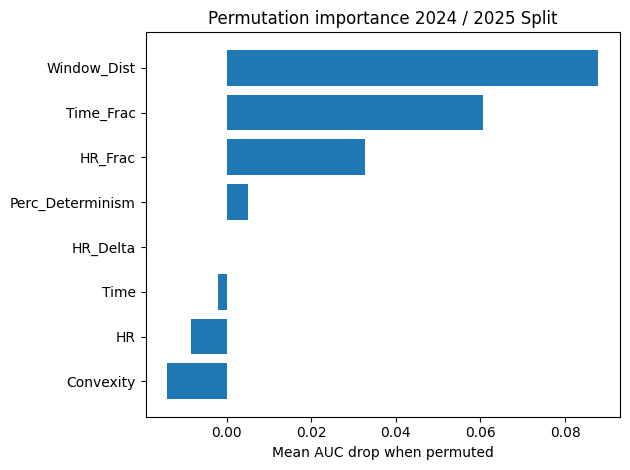

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X_test, y_test, top_k=20, n_repeats=5, random_state=42,
                                title="Permutation importance 2024 / 2025 Split"):
    r = permutation_importance(model, X_test, y_test, n_repeats=n_repeats,
                               random_state=random_state, scoring="roc_auc")
    importances = r.importances_mean
    order = np.argsort(importances)[::-1][:top_k]
    names = X_test.columns[order]
    vals  = importances[order]

    plt.figure()
    y = np.arange(len(names))
    plt.barh(y, vals)
    plt.yticks(y, names)
    plt.gca().invert_yaxis()
    plt.xlabel("Mean AUC drop when permuted")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# call after evaluating:
plot_permutation_importance(model, X_test_clean, y_test_all, top_k=20)

### Plot results 

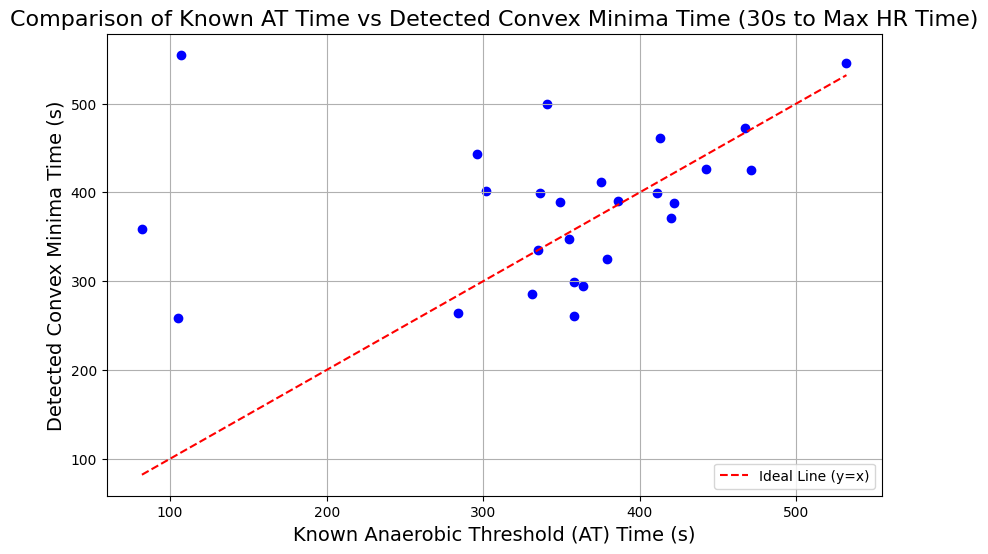

     Subject  AT_time  Convex_Minima_Time
0   001_2025      105                 259
1   002_2025       82                 359
2   003_2025      335                 335
3   004_2025      422                 388
4   005_2025      358                 299
5   006_2025      379                 325
6   007_2025      331                 286
7   008_2025      413                 461
8   009_2025      341                 500
9   010_2025      386                 390
10  011_2025      364                 294
11  012_2025      355                 347
12  013_2025      467                 473
13  014_2025      442                 426
14  015_2025      296                 443
15  016_2025      420                 371
16  017_2025      336                 399
17  018_2025      349                 389
18  019_2025      471                 425
19  020_2025      358                 261
20  021_2025      107                 555
21  022_2025      411                 399
22  023_2025      302             

In [95]:
# Convert results to DataFrame
results_df = pd.DataFrame({
    'Subject': holdout_subjects,
    'AT_time': thresholds_true,
    'Convex_Minima_Time': thresholds_pred
})

# Scatterplot of Convex Minima Time vs Known AT Time
plt.figure(figsize=(10, 6))
plt.scatter(results_df['AT_time'], results_df['Convex_Minima_Time'], color='blue')
plt.plot([results_df['AT_time'].min(), results_df['AT_time'].max()],
         [results_df['AT_time'].min(), results_df['AT_time'].max()],
         color='red', linestyle='--', label='Ideal Line (y=x)')
plt.xlabel('Known Anaerobic Threshold (AT) Time (s)', fontsize=14)
plt.ylabel('Detected Convex Minima Time (s)', fontsize=14)
plt.title('Comparison of Known AT Time vs Detected Convex Minima Time (30s to Max HR Time)', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Display the results
print(results_df)

     Subject  AT_time  Convex_Minima_Time
0   001_2025      105                 259
1   002_2025       82                 359
2   003_2025      335                 335
3   004_2025      422                 388
4   005_2025      358                 299
5   006_2025      379                 325
6   007_2025      331                 286
7   008_2025      413                 461
8   009_2025      341                 500
9   010_2025      386                 390
10  011_2025      364                 294
11  012_2025      355                 347
12  013_2025      467                 473
13  014_2025      442                 426
14  015_2025      296                 443
15  016_2025      420                 371
16  017_2025      336                 399
17  018_2025      349                 389
18  019_2025      471                 425
19  020_2025      358                 261
20  021_2025      107                 555
21  022_2025      411                 399
22  023_2025      302             

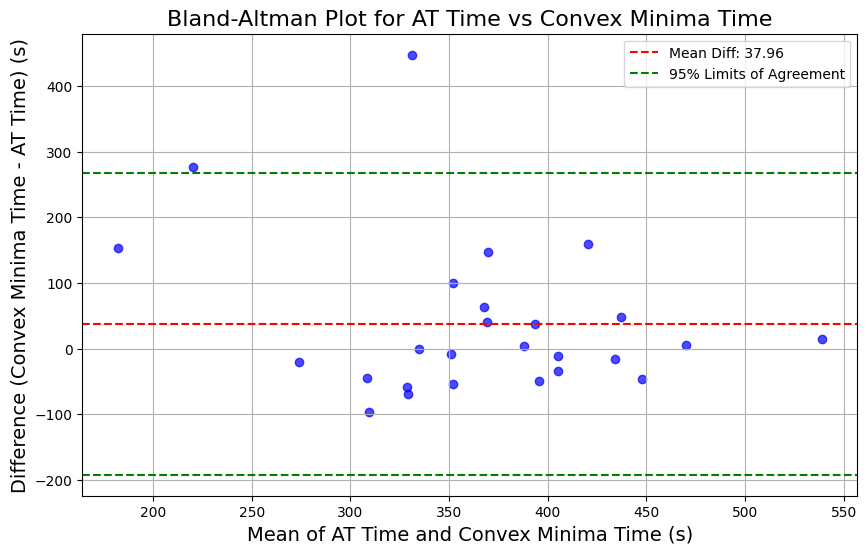

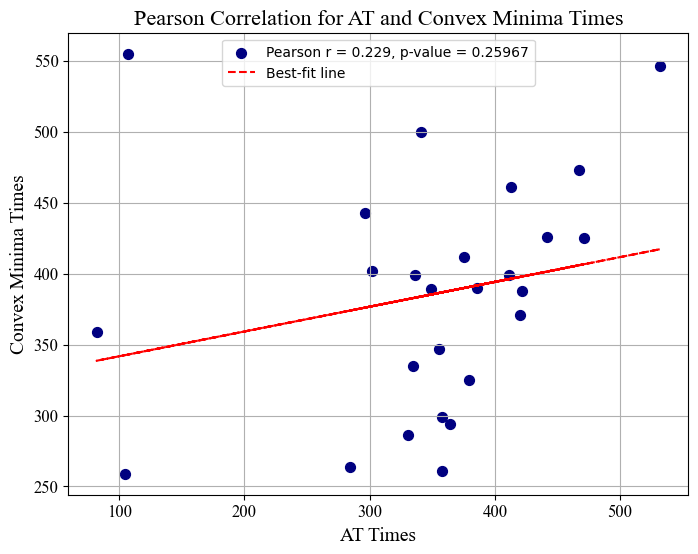

[154, 277, 0, 34, 59, 54, 45, 48, 159, 4, 70, 8, 6, 16, 147, 49, 63, 40, 46, 97, 448, 12, 100, 20, 14, 37]


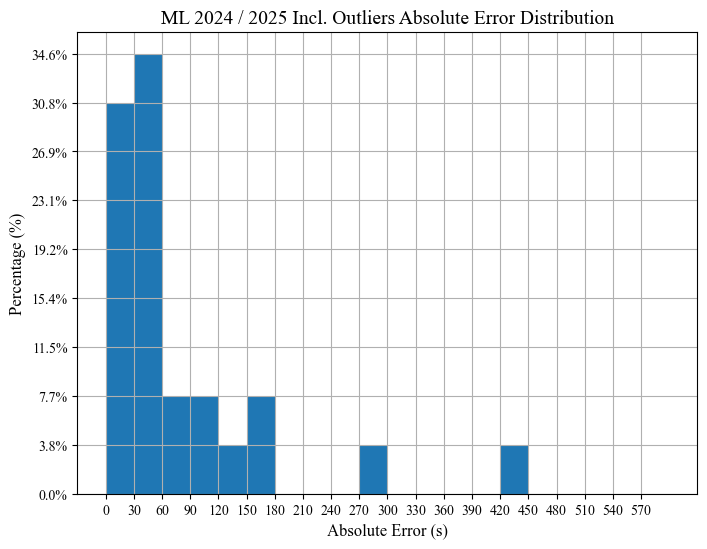

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Exclude outliers 
exclude_ids = []
filtered_results = results_df[~results_df['Subject'].isin(exclude_ids)].dropna(subset=['AT_time', 'Convex_Minima_Time'])
print(filtered_results)

# Calculate correlation between AT_time and Convex_Minima_Time
pearson_corr, pearson_p = pearsonr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
spearman_corr, spearman_p = spearmanr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
MAE, MedAE = mean_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time']), median_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])

print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.5f}")
print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.5f}")
print(f'MAE: {MAE}, MedAE: {MedAE}')

# Bland-Altman Plot
# Calculate means and differences
mean_times = (filtered_results['AT_time'] + filtered_results['Convex_Minima_Time']) / 2
diff_times = filtered_results['Convex_Minima_Time'] - filtered_results['AT_time']

# Calculate mean and standard deviation of differences
mean_diff = np.mean(diff_times)
std_diff = np.std(diff_times)

# Create Bland-Altman plot
plt.figure(figsize=(10, 6))
plt.scatter(mean_times, diff_times, color='blue', alpha=0.7)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Mean Diff: {mean_diff:.2f}')
plt.axhline(mean_diff + 1.96 * std_diff, color='green', linestyle='--', label='95% Limits of Agreement')
plt.axhline(mean_diff - 1.96 * std_diff, color='green', linestyle='--')
plt.xlabel('Mean of AT Time and Convex Minima Time (s)', fontsize=14)
plt.ylabel('Difference (Convex Minima Time - AT Time) (s)', fontsize=14)
plt.title('Bland-Altman Plot for AT Time vs Convex Minima Time', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Create scatter plot
tnrfont = {'fontname':'Times New Roman'}
plt.figure(figsize=(8, 6))
plt.scatter(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], color='navy', s=50, label=f'Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.5f}')

# Calculate and plot the line of best fit
m, b = np.polyfit(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], 1)
plt.plot(filtered_results['AT_time'], m*filtered_results['AT_time'] + b, color='red', linestyle='--', label='Best-fit line')

# Add labels and title
plt.xlabel('AT Times', fontsize = 14, **tnrfont)
plt.xticks(fontsize = 12, **tnrfont)
plt.ylabel('Convex Minima Times', fontsize = 14, **tnrfont)
plt.yticks(fontsize = 12, **tnrfont)
plt.title('Pearson Correlation for AT and Convex Minima Times', fontsize = 16, **tnrfont)
plt.legend()
plt.grid(True)
plt.show()

#create histrogram distribution of absolute error distribution 
from matplotlib.ticker import PercentFormatter

abs_error = list(abs(filtered_results['AT_time'] - filtered_results['Convex_Minima_Time']))
print(abs_error)
n_bins = 20

plt.figure(figsize = (8, 6))
bin_edges = np.linspace(0, 600, n_bins+1)

plt.hist(abs_error, bins = bin_edges, weights = np.ones(len(abs_error)) / len(abs_error), color = 'blue')

plt.xlabel('Absolute Error (s)', fontsize = 12, **tnrfont)
plt.xticks(np.arange(0, 600, step = 600/n_bins), np.arange(0, 600, step = 600/n_bins, dtype = int), fontsize=10, **tnrfont)

N = len(abs_error)  # number of samples
counts, bins, patches = plt.hist(
    abs_error, bins=bin_edges,
    weights=np.ones(N) / N
)

# Step size = one subject = 1/N
step = 1 / N

# Round max_height up to the nearest multiple of step
max_height = max(counts)
max_height_rounded = np.ceil(max_height / step) * step

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

# Ticks at multiples of step (1 subject = step)
plt.yticks(
    np.arange(0, max_height_rounded + step, step),
    fontsize=10, **tnrfont
)

plt.ylabel('Percentage (%)', fontsize = 12, **tnrfont)

plt.title('ML 2024 / 2025 Incl. Outliers Absolute Error Distribution', fontsize = 14, **tnrfont)
plt.grid(True)
plt.show()

### Exclude early AnT outliers for comparison with rule-based method

     Subject  AT_time  Convex_Minima_Time
2   003_2025      335                 335
3   004_2025      422                 388
4   005_2025      358                 299
5   006_2025      379                 325
6   007_2025      331                 286
7   008_2025      413                 461
8   009_2025      341                 500
9   010_2025      386                 390
10  011_2025      364                 294
11  012_2025      355                 347
12  013_2025      467                 473
13  014_2025      442                 426
14  015_2025      296                 443
15  016_2025      420                 371
16  017_2025      336                 399
17  018_2025      349                 389
18  019_2025      471                 425
19  020_2025      358                 261
21  022_2025      411                 399
22  023_2025      302                 402
23  024_2025      284                 264
24  025_2025      532                 546
25  026_2025      375             

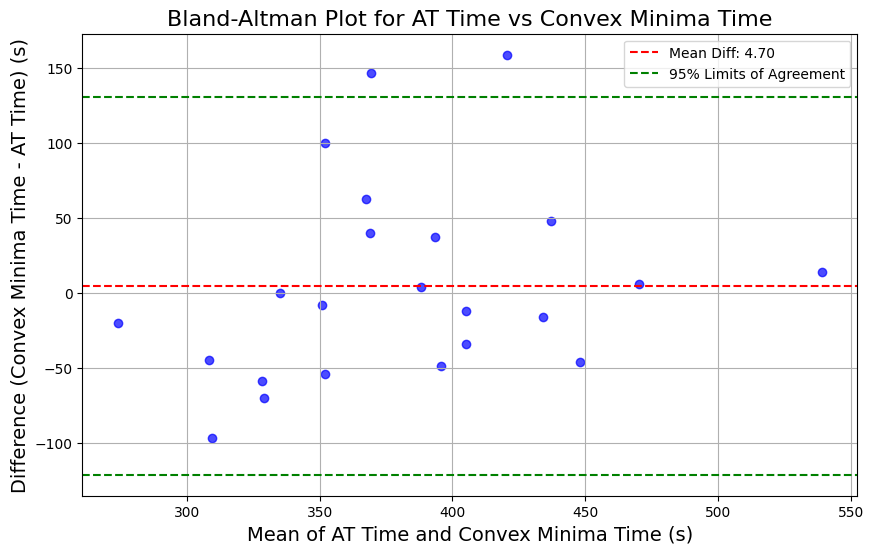

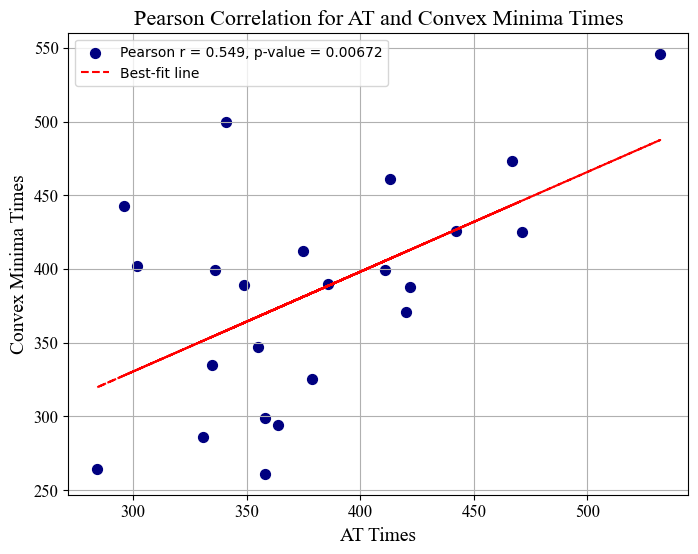

[0, 34, 59, 54, 45, 48, 159, 4, 70, 8, 6, 16, 147, 49, 63, 40, 46, 97, 12, 100, 20, 14, 37]


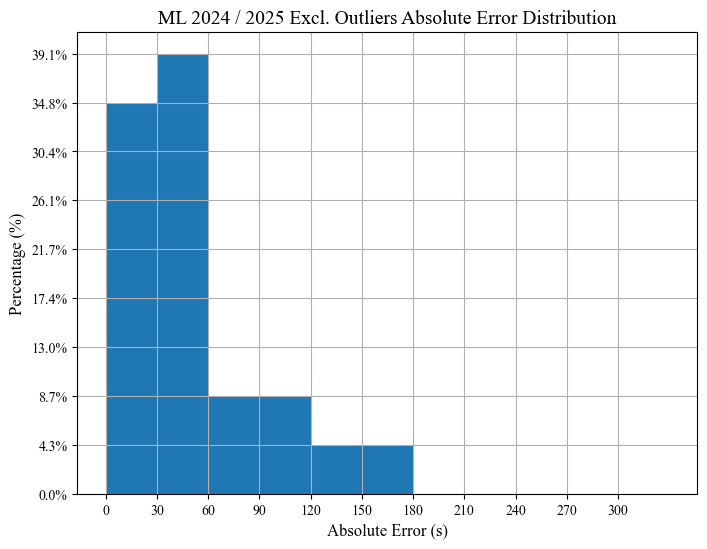

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Exclude early AnT outliers 
exclude_ids = ['001_2025', '002_2025', '021_2025']
filtered_results = results_df[~results_df['Subject'].isin(exclude_ids)].dropna(subset=['AT_time', 'Convex_Minima_Time'])
print(filtered_results)

# Calculate correlation between AT_time and Convex_Minima_Time
pearson_corr, pearson_p = pearsonr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
spearman_corr, spearman_p = spearmanr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
MAE, MedAE = mean_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time']), median_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])

print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.5f}")
print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.5f}")
print(f'MAE: {MAE}, MedAE: {MedAE}')

# Bland-Altman Plot
# Calculate means and differences
mean_times = (filtered_results['AT_time'] + filtered_results['Convex_Minima_Time']) / 2
diff_times = filtered_results['Convex_Minima_Time'] - filtered_results['AT_time']

# Calculate mean and standard deviation of differences
mean_diff = np.mean(diff_times)
std_diff = np.std(diff_times)

# Create Bland-Altman plot
plt.figure(figsize=(10, 6))
plt.scatter(mean_times, diff_times, color='blue', alpha=0.7)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Mean Diff: {mean_diff:.2f}')
plt.axhline(mean_diff + 1.96 * std_diff, color='green', linestyle='--', label='95% Limits of Agreement')
plt.axhline(mean_diff - 1.96 * std_diff, color='green', linestyle='--')
plt.xlabel('Mean of AT Time and Convex Minima Time (s)', fontsize=14)
plt.ylabel('Difference (Convex Minima Time - AT Time) (s)', fontsize=14)
plt.title('Bland-Altman Plot for AT Time vs Convex Minima Time', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Create scatter plot
tnrfont = {'fontname':'Times New Roman'}
plt.figure(figsize=(8, 6))
plt.scatter(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], color='navy', s=50, label=f'Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.5f}')

# Calculate and plot the line of best fit
m, b = np.polyfit(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], 1)
plt.plot(filtered_results['AT_time'], m*filtered_results['AT_time'] + b, color='red', linestyle='--', label='Best-fit line')

# Add labels and title
plt.xlabel('AT Times', fontsize = 14, **tnrfont)
plt.xticks(fontsize = 12, **tnrfont)
plt.ylabel('Convex Minima Times', fontsize = 14, **tnrfont)
plt.yticks(fontsize = 12, **tnrfont)
plt.title('Pearson Correlation for AT and Convex Minima Times', fontsize = 16, **tnrfont)
plt.legend()
plt.grid(True)
plt.show()

#create histrogram distribution of absolute error distribution 
from matplotlib.ticker import PercentFormatter

abs_error = list(abs(filtered_results['AT_time'] - filtered_results['Convex_Minima_Time']))
print(abs_error)
n_bins = 11

plt.figure(figsize = (8, 6))
bin_edges = np.linspace(0, 330, n_bins+1)

plt.hist(abs_error, bins = bin_edges, weights = np.ones(len(abs_error)) / len(abs_error), color = 'blue')

plt.xlabel('Absolute Error (s)', fontsize = 12, **tnrfont)
plt.xticks(np.arange(0, 330, step = 330/n_bins), np.arange(0, 330, step = 330/n_bins, dtype = int), fontsize=10, **tnrfont)

N = len(abs_error)  # number of samples
counts, bins, patches = plt.hist(
    abs_error, bins=bin_edges,
    weights=np.ones(N) / N
)

# Step size = one subject = 1/N
step = 1 / N

# Round max_height up to the nearest multiple of step
max_height = max(counts)
max_height_rounded = np.ceil(max_height / step) * step

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

# Ticks at multiples of step (1 subject = step)
plt.yticks(
    np.arange(0, max_height_rounded + step, step),
    fontsize=10, **tnrfont
)

plt.ylabel('Percentage (%)', fontsize = 12, **tnrfont)

plt.title('ML 2024 / 2025 Excl. Outliers Absolute Error Distribution', fontsize = 14, **tnrfont)
plt.grid(True)
plt.show()

## Carry out LOSOCV for XGBoost for a performance metric leveraging the full dataset
As the ML pipeline had parameters that were previously tuned using this subjects from the 2024 dataset (the primary window feature), these results are more representative of the general potential of the pipeline, exploratory rather than concrete results.

In [80]:
labels = df_long['Label'].reset_index(drop=True)
features_all = df_long.drop(['Label', 'Candidate_ID'], axis = 1)

print(labels)
print(features_all)

0       0
1       0
2       0
3       0
4       0
       ..
5044    0
5045    0
5046    0
5047    0
5048    0
Name: Label, Length: 5049, dtype: int64
       Subject  Time  Time_Frac  Window_Dist     HR  HR_Delta   HR_Frac  \
0     001_2024     2   0.005208     0.719792  112.0       0.0  0.589474   
1     001_2024     5   0.013021     0.711979  113.0       1.0  0.594737   
2     001_2024     7   0.018229     0.706771  113.0       1.0  0.594737   
3     001_2024    10   0.026042     0.698958  114.0       2.0  0.600000   
4     001_2024    13   0.033854     0.691146  114.0       2.0  0.600000   
...        ...   ...        ...          ...    ...       ...       ...   
5044  026_2025   400   0.692042     0.032958  156.0      46.0  0.906977   
5045  026_2025   408   0.705882     0.019118  157.0      47.0  0.912791   
5046  026_2025   412   0.712803     0.012197  157.0      47.0  0.912791   
5047  026_2025   417   0.721453     0.003547  157.0      47.0  0.912791   
5048  026_2025   419   0.

In [87]:
holdout_subjects = []

import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, median_absolute_error

train_mask = ~features_all['Subject'].isin(holdout_subjects)
test_mask = features_all['Subject'].isin(holdout_subjects)

X_train_all = features_all[train_mask]
X_train_clean = X_train_all.drop(columns = ['Subject'])
y_train_all = labels[train_mask]

X_test_all = features_all[test_mask].copy()
X_test_clean = X_test_all.drop(columns = ['Subject'])
y_test_all = labels[test_mask].copy()

#use GroupKFold to ensure subject-wise split 
gkf = GroupKFold(n_splits = 49)
groups = features_all['Subject'][train_mask]

#define models in dict 
models = {
     'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.5, colsample_bytree=0.8,
    random_state=42,  eval_metric='logloss', reg_lambda = 1)
}

#might want to tune certain parameters in cv: RF max_depth & min_samples_leaf, LG C, XGB reg_lambda = 1

#initialise results dict 
pred_all = []
true_all = []

#for each fold 
for train_idx, test_idx in gkf.split(X_train_all, y_train_all, groups = groups):

    X_train_ref, X_test_ref = X_train_all.iloc[train_idx], X_train_all.iloc[test_idx] #keep reference dict for subject-wise loop
    X_train, X_test = X_train_clean.iloc[train_idx], X_train_clean.iloc[test_idx]
    y_train, y_test = y_train_all.iloc[train_idx], y_train_all.iloc[test_idx]

    #for each model 
    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None #for AUC (logistic regression)
        thresholds_pred = []
        thresholds_true = []

        for subject in X_test_ref['Subject'].unique():  

            AT_true = AT_dict[f'{subject}']
            thresholds_true.append(AT_true)

            mask = X_test_ref['Subject'] == subject 
            preds = y_pred[mask]
            probs = y_prob[mask] if y_prob is not None else None
            times = X_test_ref.loc[mask, 'Time'].values

            #if only one predicted LT (best case)
            if sum(preds) == 1:
                
                threshold = times[np.where(preds == 1)[0][0]]

            #if more than one predicted LT, pick highest probability candidate
            elif sum(preds) > 1:
                
                probs_index = np.argmax(probs)
                threshold = times[probs_index]    

            #if no predicted LT, pick highest probability candidate 
            else:
                
                probs_index = np.argmax(probs)
                threshold = times[probs_index]  
        
            thresholds_pred.append(threshold)

        print(thresholds_true, thresholds_pred)
        pred_all.append(int(thresholds_pred[0]))
        true_all.append(int(thresholds_true[0]))

print(pred_all, true_all)
MAE = mean_absolute_error(true_all, pred_all)
MedAE = median_absolute_error(true_all, pred_all)
print(f'MAE: {MAE}, MedAE: {MedAE}')


[498] [530]
[473] [468]
[521] [461]
[341] [415]
[532] [454]
[107] [555]
[467] [484]
[82] [337]
[455] [291]
[302] [402]
[379] [493]
[411] [539]
[303] [434]
[413] [463]
[385] [413]
[320] [345]
[286] [334]
[358] [375]
[296] [443]
[422] [359]
[375] [412]
[425] [284]
[331] [357]
[315] [333]
[298] [368]
[364] [364]
[471] [468]
[391] [370]
[335] [335]
[358] [299]
[105] [299]
[302] [301]
[420] [406]
[349] [380]
[386] [351]
[288] [352]
[442] [426]
[202] [363]
[283] [330]
[270] [288]
[336] [399]
[284] [246]
[494] [286]
[195] [218]
[355] [347]
[355] [209]
[301] [218]
[225] [16]
[0] [1]
[530, 468, 461, 415, 454, 555, 484, 337, 291, 402, 493, 539, 434, 463, 413, 345, 334, 375, 443, 359, 412, 284, 357, 333, 368, 364, 468, 370, 335, 299, 299, 301, 406, 380, 351, 352, 426, 363, 330, 288, 399, 246, 286, 218, 347, 209, 218, 16, 1] [498, 473, 521, 341, 532, 107, 467, 82, 455, 302, 379, 411, 303, 413, 385, 320, 286, 358, 296, 422, 375, 425, 331, 315, 298, 364, 471, 391, 335, 358, 105, 302, 420, 349, 386, 

### Feature Importance 

MAE: 75.89795918367346, MedAE: 48.0


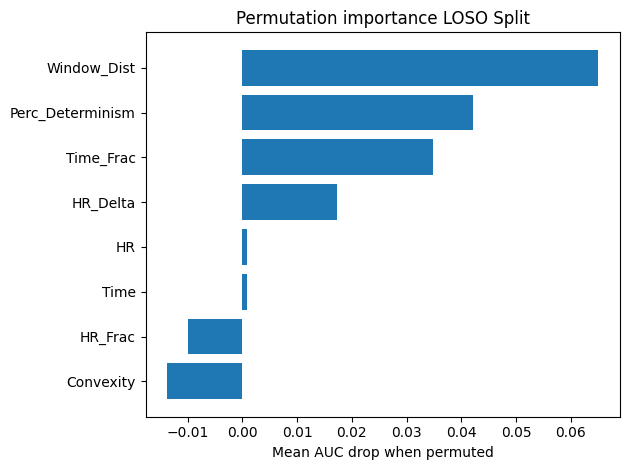

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# store results for feature importances
all_importances = []

for train_idx, test_idx in gkf.split(X_train_all, y_train_all, groups=groups):

    X_train_ref, X_test_ref = X_train_all.iloc[train_idx], X_train_all.iloc[test_idx]
    X_train, X_test = X_train_clean.iloc[train_idx], X_train_clean.iloc[test_idx]
    y_train, y_test = y_train_all.iloc[train_idx], y_train_all.iloc[test_idx]

    for name, model in models.items():
        model.fit(X_train, y_train)

        # --- existing threshold prediction logic ---
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

        thresholds_pred, thresholds_true = [], []
        for subject in X_test_ref['Subject'].unique():  
            AT_true = AT_dict[f'{subject}']
            thresholds_true.append(AT_true)

            mask = X_test_ref['Subject'] == subject 
            preds = y_pred[mask]
            probs = y_prob[mask] if y_prob is not None else None
            times = X_test_ref.loc[mask, 'Time'].values

            if sum(preds) == 1:
                threshold = times[np.where(preds == 1)[0][0]]
            elif sum(preds) > 1:
                threshold = times[np.argmax(probs)]
            else:
                threshold = times[np.argmax(probs)]

            thresholds_pred.append(threshold)

        pred_all.append(int(thresholds_pred[0]))
        true_all.append(int(thresholds_true[0]))

        # --- permutation importance for this fold ---
        r = permutation_importance(
            model, X_test, y_test,
            n_repeats=5, random_state=42, scoring="roc_auc"
        )
        all_importances.append(r.importances_mean)

# compute overall performance
MAE = mean_absolute_error(true_all, pred_all)
MedAE = median_absolute_error(true_all, pred_all)
print(f'MAE: {MAE}, MedAE: {MedAE}')

# average feature importances across folds
avg_importances = np.mean(all_importances, axis=0)

# plot top-k
def plot_avg_importance(importances, feature_names, top_k=20, title="Permutation importance LOSO Split"):
    order = np.argsort(importances)[::-1][:top_k]
    names = feature_names[order]
    vals  = importances[order]

    plt.figure()
    y = np.arange(len(names))
    plt.barh(y, vals)
    plt.yticks(y, names)
    plt.gca().invert_yaxis()
    plt.xlabel("Mean AUC drop when permuted")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_avg_importance(avg_importances, X_train_clean.columns.to_numpy(), top_k=20)


### Plot results 

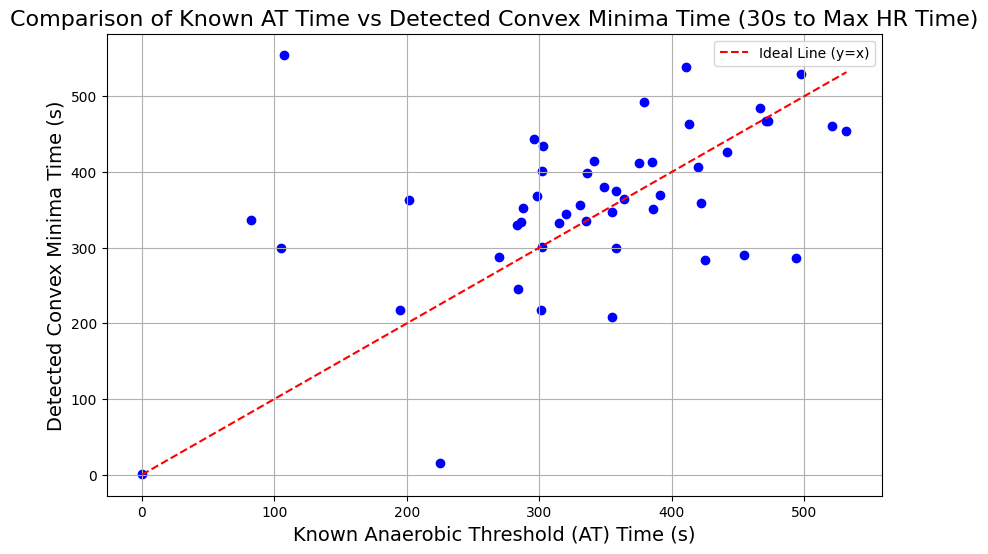

     Subject  AT_time  Convex_Minima_Time
0   001_2024      498                 530
1   001_2025      473                 468
2   002_2024      521                 461
3   002_2025      341                 415
4   003_2024      532                 454
5   003_2025      107                 555
6   004_2024      467                 484
7   004_2025       82                 337
8   005_2024      455                 291
9   005_2025      302                 402
10  006_2024      379                 493
11  006_2025      411                 539
12  007_2024      303                 434
13  007_2025      413                 463
14  008_2024      385                 413
15  008_2025      320                 345
16  009_2025      286                 334
17  010_2024      358                 375
18  010_2025      296                 443
19  011_2025      422                 359
20  012_2024      375                 412
21  012_2025      425                 284
22  013_2024      331             

In [88]:
# Convert results to DataFrame
results_df = pd.DataFrame({
    'Subject': subjects, #NB subjects in wrong order 
    'AT_time': true_all,
    'Convex_Minima_Time': pred_all
})

# Scatterplot of Convex Minima Time vs Known AT Time
plt.figure(figsize=(10, 6))
plt.scatter(results_df['AT_time'], results_df['Convex_Minima_Time'], color='blue')
plt.plot([results_df['AT_time'].min(), results_df['AT_time'].max()],
         [results_df['AT_time'].min(), results_df['AT_time'].max()],
         color='red', linestyle='--', label='Ideal Line (y=x)')
plt.xlabel('Known Anaerobic Threshold (AT) Time (s)', fontsize=14)
plt.ylabel('Detected Convex Minima Time (s)', fontsize=14)
plt.title('Comparison of Known AT Time vs Detected Convex Minima Time (30s to Max HR Time)', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Display the results
print(results_df)

     Subject  AT_time  Convex_Minima_Time
0   001_2024      498                 530
1   001_2025      473                 468
2   002_2024      521                 461
3   002_2025      341                 415
4   003_2024      532                 454
5   003_2025      107                 555
6   004_2024      467                 484
7   004_2025       82                 337
8   005_2024      455                 291
9   005_2025      302                 402
10  006_2024      379                 493
11  006_2025      411                 539
12  007_2024      303                 434
13  007_2025      413                 463
14  008_2024      385                 413
15  008_2025      320                 345
16  009_2025      286                 334
17  010_2024      358                 375
18  010_2025      296                 443
19  011_2025      422                 359
20  012_2024      375                 412
21  012_2025      425                 284
22  013_2024      331             

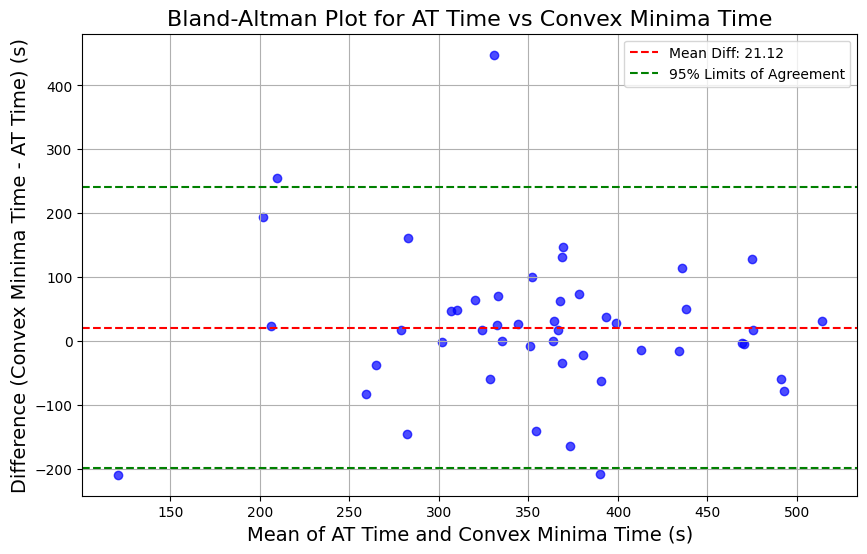

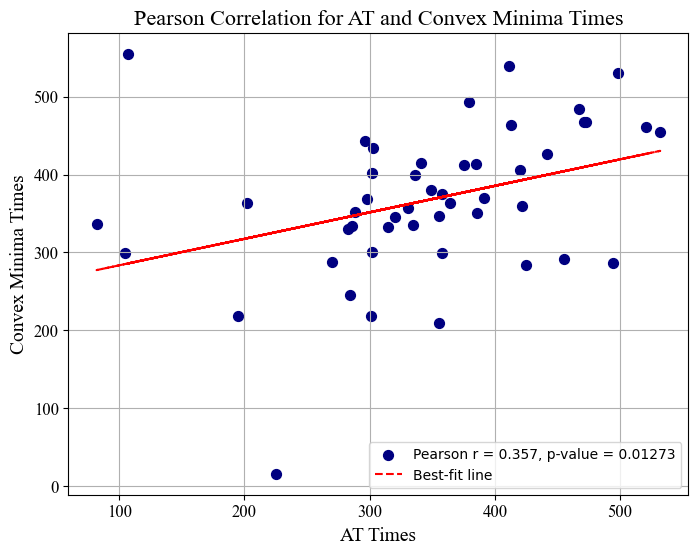

[32, 5, 60, 74, 78, 448, 17, 255, 164, 100, 114, 128, 131, 50, 28, 25, 48, 17, 147, 63, 37, 141, 26, 18, 70, 0, 3, 21, 0, 59, 194, 1, 14, 31, 35, 64, 16, 161, 47, 18, 63, 38, 208, 23, 8, 146, 83, 209]


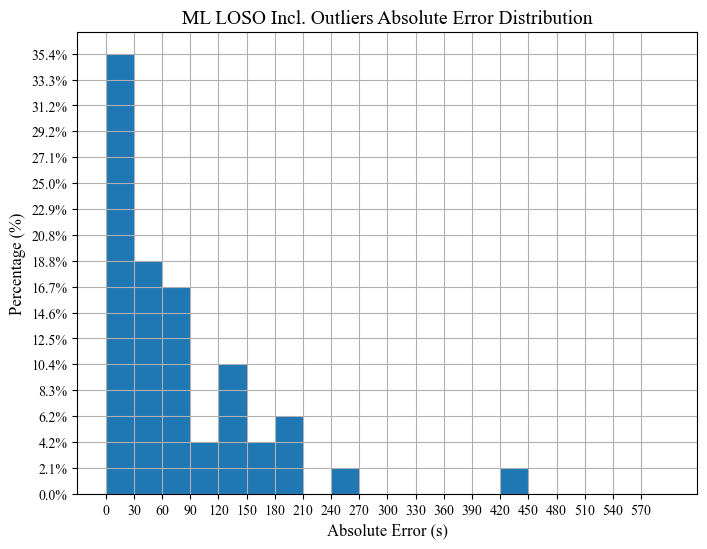

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Exclude outliers 
exclude_ids = ['026_2025']
filtered_results = results_df[~results_df['Subject'].isin(exclude_ids)].dropna(subset=['AT_time', 'Convex_Minima_Time'])
print(filtered_results)

# Calculate correlation between AT_time and Convex_Minima_Time
pearson_corr, pearson_p = pearsonr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
spearman_corr, spearman_p = spearmanr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
MAE, MedAE = mean_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time']), median_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])

print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.5f}")
print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.5f}")
print(f'MAE: {MAE}, MedAE: {MedAE}')

# Bland-Altman Plot
# Calculate means and differences
mean_times = (filtered_results['AT_time'] + filtered_results['Convex_Minima_Time']) / 2
diff_times = filtered_results['Convex_Minima_Time'] - filtered_results['AT_time']

# Calculate mean and standard deviation of differences
mean_diff = np.mean(diff_times)
std_diff = np.std(diff_times)

# Create Bland-Altman plot
plt.figure(figsize=(10, 6))
plt.scatter(mean_times, diff_times, color='blue', alpha=0.7)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Mean Diff: {mean_diff:.2f}')
plt.axhline(mean_diff + 1.96 * std_diff, color='green', linestyle='--', label='95% Limits of Agreement')
plt.axhline(mean_diff - 1.96 * std_diff, color='green', linestyle='--')
plt.xlabel('Mean of AT Time and Convex Minima Time (s)', fontsize=14)
plt.ylabel('Difference (Convex Minima Time - AT Time) (s)', fontsize=14)
plt.title('Bland-Altman Plot for AT Time vs Convex Minima Time', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Create scatter plot
tnrfont = {'fontname':'Times New Roman'}
plt.figure(figsize=(8, 6))
plt.scatter(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], color='navy', s=50, label=f'Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.5f}')

# Calculate and plot the line of best fit
m, b = np.polyfit(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], 1)
plt.plot(filtered_results['AT_time'], m*filtered_results['AT_time'] + b, color='red', linestyle='--', label='Best-fit line')

# Add labels and title
plt.xlabel('AT Times', fontsize = 14, **tnrfont)
plt.xticks(fontsize = 12, **tnrfont)
plt.ylabel('Convex Minima Times', fontsize = 14, **tnrfont)
plt.yticks(fontsize = 12, **tnrfont)
plt.title('Pearson Correlation for AT and Convex Minima Times', fontsize = 16, **tnrfont)
plt.legend()
plt.grid(True)
plt.show()

#create histrogram distribution of absolute error distribution 
from matplotlib.ticker import PercentFormatter

abs_error = list(abs(filtered_results['AT_time'] - filtered_results['Convex_Minima_Time']))
print(abs_error)
n_bins = 20

plt.figure(figsize = (8, 6))
bin_edges = np.linspace(0, 600, n_bins+1)

plt.hist(abs_error, bins = bin_edges, weights = np.ones(len(abs_error)) / len(abs_error), color = 'blue')

plt.xlabel('Absolute Error (s)', fontsize = 12, **tnrfont)
plt.xticks(np.arange(0, 600, step = 600/n_bins), np.arange(0, 600, step = 600/n_bins, dtype = int), fontsize=10, **tnrfont)

N = len(abs_error)  # number of samples
counts, bins, patches = plt.hist(
    abs_error, bins=bin_edges,
    weights=np.ones(N) / N
)

# Step size = one subject = 1/N
step = 1 / N

# Round max_height up to the nearest multiple of step
max_height = max(counts)
max_height_rounded = np.ceil(max_height / step) * step

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

# Ticks at multiples of step (1 subject = step)
plt.yticks(
    np.arange(0, max_height_rounded + step, step),
    fontsize=10, **tnrfont
)

plt.ylabel('Percentage (%)', fontsize = 12, **tnrfont)

plt.title('ML LOSO Incl. Outliers Absolute Error Distribution', fontsize = 14, **tnrfont)
plt.grid(True)
plt.show()

     Subject  AT_time  Convex_Minima_Time
0   001_2024      498                 530
1   001_2025      473                 468
2   002_2024      521                 461
3   002_2025      341                 415
4   003_2024      532                 454
6   004_2024      467                 484
8   005_2024      455                 291
9   005_2025      302                 402
10  006_2024      379                 493
11  006_2025      411                 539
12  007_2024      303                 434
13  007_2025      413                 463
14  008_2024      385                 413
15  008_2025      320                 345
16  009_2025      286                 334
17  010_2024      358                 375
18  010_2025      296                 443
19  011_2025      422                 359
20  012_2024      375                 412
21  012_2025      425                 284
22  013_2024      331                 357
23  013_2025      315                 333
24  014_2024      298             

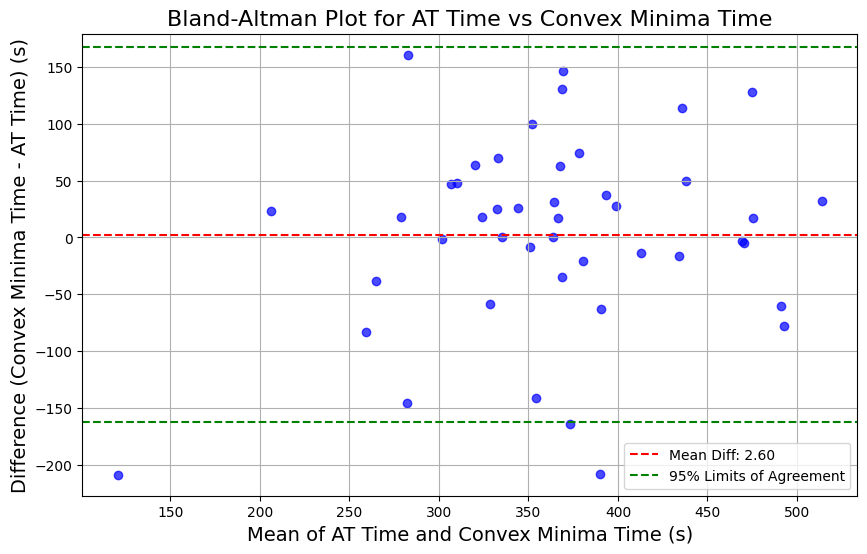

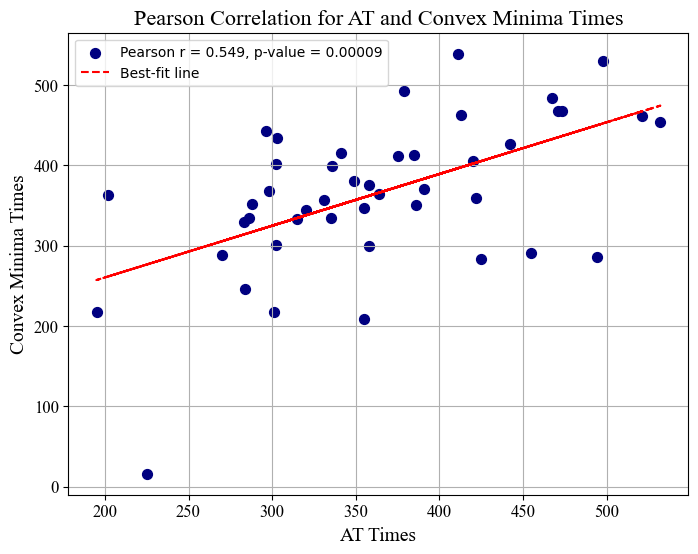

[32, 5, 60, 74, 78, 17, 164, 100, 114, 128, 131, 50, 28, 25, 48, 17, 147, 63, 37, 141, 26, 18, 70, 0, 3, 21, 0, 59, 1, 14, 31, 35, 64, 16, 161, 47, 18, 63, 38, 208, 23, 8, 146, 83, 209]


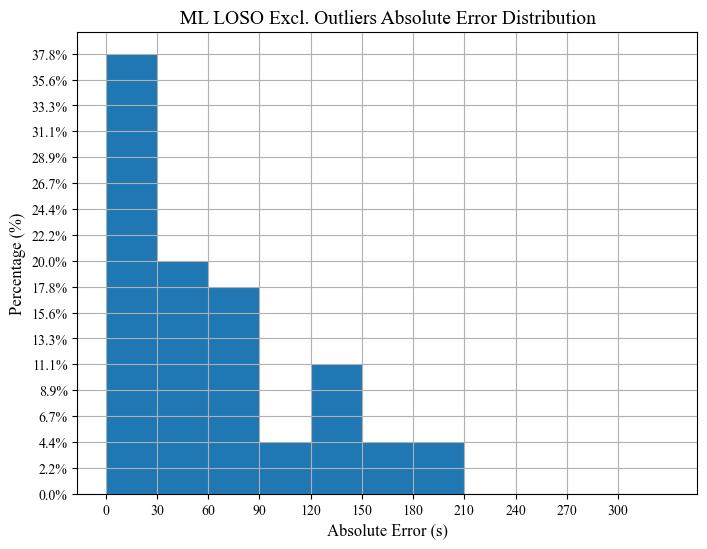

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Exclude outliers 
exclude_ids = ['026_2025', '017_2024', '004_2025', '003_2025'] #subject ids in wrong order so manually found
filtered_results = results_df[~results_df['Subject'].isin(exclude_ids)].dropna(subset=['AT_time', 'Convex_Minima_Time'])
print(filtered_results)

# Calculate correlation between AT_time and Convex_Minima_Time
pearson_corr, pearson_p = pearsonr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
spearman_corr, spearman_p = spearmanr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
MAE, MedAE = mean_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time']), median_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])

print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.5f}")
print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.5f}")
print(f'MAE: {MAE}, MedAE: {MedAE}')

# Bland-Altman Plot
# Calculate means and differences
mean_times = (filtered_results['AT_time'] + filtered_results['Convex_Minima_Time']) / 2
diff_times = filtered_results['Convex_Minima_Time'] - filtered_results['AT_time']

# Calculate mean and standard deviation of differences
mean_diff = np.mean(diff_times)
std_diff = np.std(diff_times)

# Create Bland-Altman plot
plt.figure(figsize=(10, 6))
plt.scatter(mean_times, diff_times, color='blue', alpha=0.7)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Mean Diff: {mean_diff:.2f}')
plt.axhline(mean_diff + 1.96 * std_diff, color='green', linestyle='--', label='95% Limits of Agreement')
plt.axhline(mean_diff - 1.96 * std_diff, color='green', linestyle='--')
plt.xlabel('Mean of AT Time and Convex Minima Time (s)', fontsize=14)
plt.ylabel('Difference (Convex Minima Time - AT Time) (s)', fontsize=14)
plt.title('Bland-Altman Plot for AT Time vs Convex Minima Time', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Create scatter plot
tnrfont = {'fontname':'Times New Roman'}
plt.figure(figsize=(8, 6))
plt.scatter(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], color='navy', s=50, label=f'Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.5f}')

# Calculate and plot the line of best fit
m, b = np.polyfit(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], 1)
plt.plot(filtered_results['AT_time'], m*filtered_results['AT_time'] + b, color='red', linestyle='--', label='Best-fit line')

# Add labels and title
plt.xlabel('AT Times', fontsize = 14, **tnrfont)
plt.xticks(fontsize = 12, **tnrfont)
plt.ylabel('Convex Minima Times', fontsize = 14, **tnrfont)
plt.yticks(fontsize = 12, **tnrfont)
plt.title('Pearson Correlation for AT and Convex Minima Times', fontsize = 16, **tnrfont)
plt.legend()
plt.grid(True)
plt.show()

#create histrogram distribution of absolute error distribution 
from matplotlib.ticker import PercentFormatter

abs_error = list(abs(filtered_results['AT_time'] - filtered_results['Convex_Minima_Time']))
print(abs_error)
n_bins = 11

plt.figure(figsize = (8, 6))
bin_edges = np.linspace(0, 330, n_bins+1)

plt.hist(abs_error, bins = bin_edges, weights = np.ones(len(abs_error)) / len(abs_error), color = 'blue')

plt.xlabel('Absolute Error (s)', fontsize = 12, **tnrfont)
plt.xticks(np.arange(0, 330, step = 330/n_bins), np.arange(0, 330, step = 330/n_bins, dtype = int), fontsize=10, **tnrfont)

N = len(abs_error)  # number of samples
counts, bins, patches = plt.hist(
    abs_error, bins=bin_edges,
    weights=np.ones(N) / N
)

# Step size = one subject = 1/N
step = 1 / N

# Round max_height up to the nearest multiple of step
max_height = max(counts)
max_height_rounded = np.ceil(max_height / step) * step

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

# Ticks at multiples of step (1 subject = step)
plt.yticks(
    np.arange(0, max_height_rounded + step, step),
    fontsize=10, **tnrfont
)

plt.ylabel('Percentage (%)', fontsize = 12, **tnrfont)

plt.title('ML LOSO Excl. Outliers Absolute Error Distribution', fontsize = 14, **tnrfont)
plt.grid(True)
plt.show()